In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("./Credit_Card_Dataset.csv")

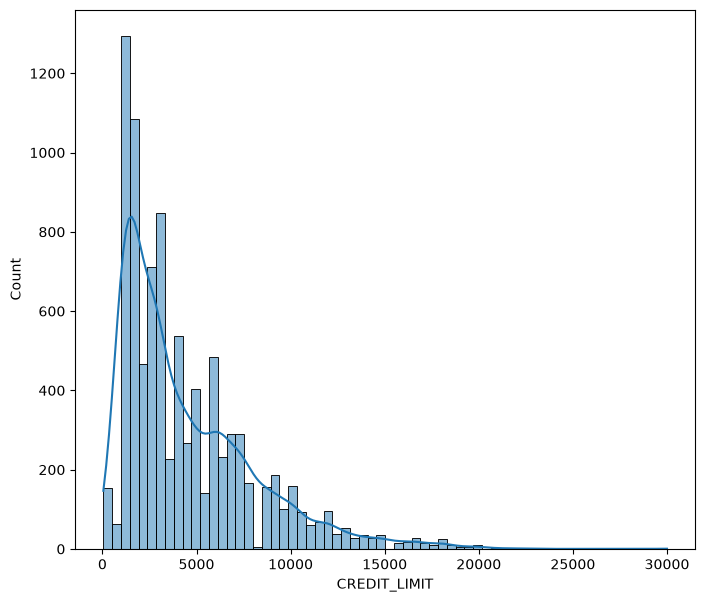

In [3]:
plt.figure(figsize=(8,7))
sns.histplot(df["CREDIT_LIMIT"], kde=True)
plt.show()

In [4]:
dfcopy = df.copy()

In [5]:
dfcopy.fillna({
    "CREDIT_LIMIT": dfcopy["CREDIT_LIMIT"].median(),
    "MINIMUM_PAYMENTS": dfcopy["MINIMUM_PAYMENTS"].median(),
}, inplace=True)

dfcopy.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [6]:
dfcopy.drop(columns=["CUST_ID"], inplace=True)

dfcopy.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(dfcopy)

scaled_df = pd.DataFrame(scaled_data, columns=dfcopy.columns)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [8]:
print("Mean of each column: \n ", scaled_df.mean())

print("Standard deviation of each column: \n", scaled_df.std())

Mean of each column: 
  BALANCE                             8.891708e-17
BALANCE_FREQUENCY                   2.286439e-16
PURCHASES                           0.000000e+00
ONEOFF_PURCHASES                    3.175610e-17
INSTALLMENTS_PURCHASES              2.540488e-17
CASH_ADVANCE                        1.016195e-16
PURCHASES_FREQUENCY                -1.841854e-16
ONEOFF_PURCHASES_FREQUENCY         -8.891708e-17
PURCHASES_INSTALLMENTS_FREQUENCY    4.604634e-17
CASH_ADVANCE_FREQUENCY              5.557317e-17
CASH_ADVANCE_TRX                   -2.540488e-17
PURCHASES_TRX                      -2.540488e-17
CREDIT_LIMIT                        1.270244e-16
PAYMENTS                           -3.810732e-17
MINIMUM_PAYMENTS                    5.716098e-17
PRC_FULL_PAYMENT                    0.000000e+00
TENURE                              2.794537e-16
dtype: float64
Standard deviation of each column: 
 BALANCE                             1.000056
BALANCE_FREQUENCY                   1.000056
P

## Elbow scaling

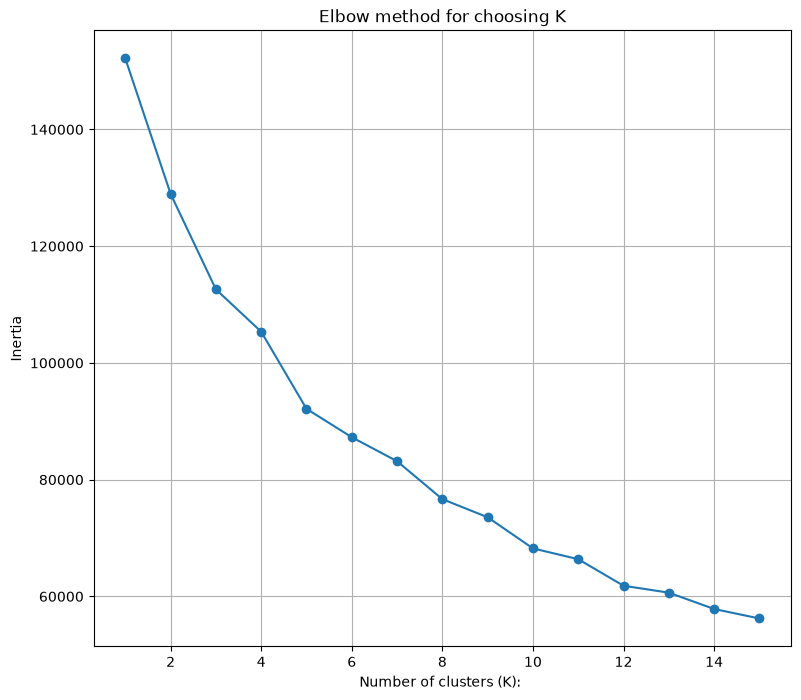

In [9]:
inertia_values = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9,8))
plt.plot(range(1, 16), inertia_values, marker="o")
plt.xlabel("Number of clusters (K): ")
plt.ylabel("Inertia")
plt.title("Elbow method for choosing K")
plt.grid(True)
plt.show()

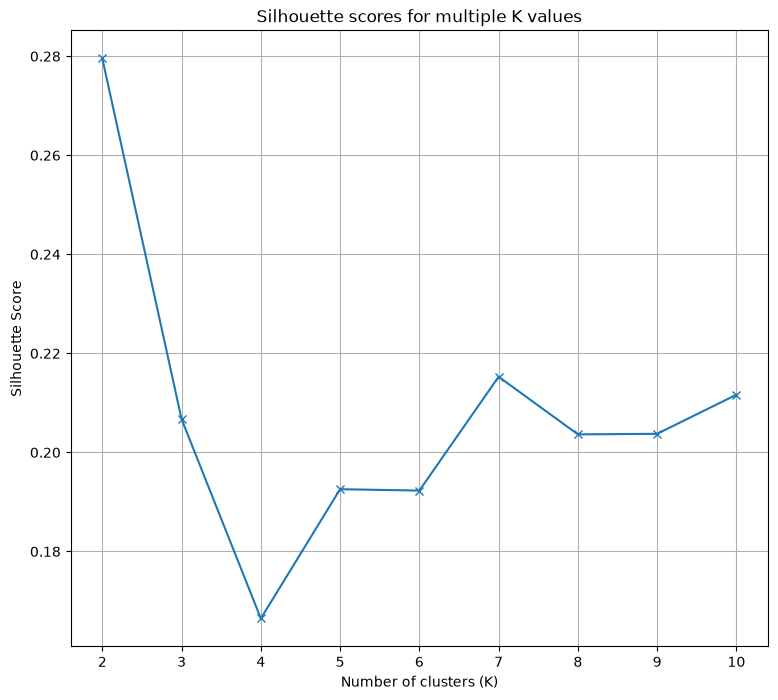

In [10]:
silhouette_scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(9,8))
plt.plot(range(2, 11), silhouette_scores, marker="x")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette scores for multiple K values")
plt.grid(True)
plt.show()

# Trying for K = 5

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_df)

df["Cluster"] = kmeans.labels_

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,3
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


In [12]:
df["Cluster"].value_counts()

Cluster
2    3164
3    3047
4    1357
0     987
1     395
Name: count, dtype: int64

PCA visualization

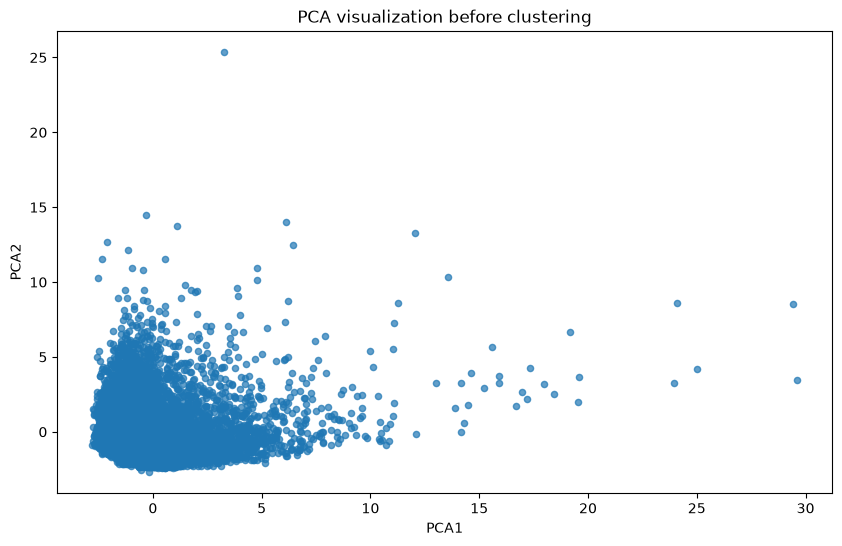

In [13]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(10,6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=20, alpha=0.7)
plt.title("PCA visualization before clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

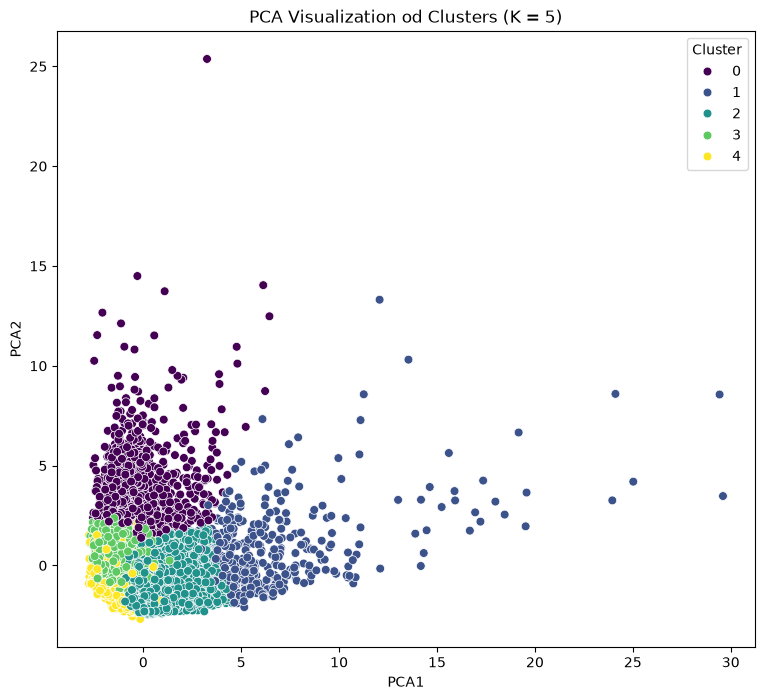

In [14]:
pca = PCA(n_components=2)
pca_components= pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])
pca_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(9,8))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="viridis", data=pca_df ,s=40)
plt.title("PCA Visualization od Clusters (K = 5)")
plt.show()

In [15]:
cluster_profile = df.drop(columns=["CUST_ID"]).groupby("Cluster").mean()

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4903.428600,0.967095,553.101884,348.463283,204.741611,4983.093638,0.313999,0.153460,0.204131,0.507563,15.499493,8.604863,8062.618587,3858.809663,2085.737924,0.038158,11.413374
1,3588.990384,0.986874,7815.732886,5203.519089,2613.732785,661.788641,0.944730,0.740963,0.785823,0.071074,2.106329,90.351899,9769.620253,7409.095001,2000.402710,0.291103,11.949367
2,930.357741,0.962886,1299.705338,633.167216,666.735496,226.754889,0.897121,0.313579,0.719275,0.044345,0.828382,23.034766,4272.477078,1388.751132,648.353289,0.264987,11.610303
3,1526.118239,0.965743,255.461815,206.435714,49.375189,794.776687,0.159002,0.090819,0.067276,0.160534,3.037742,2.882179,3244.229297,958.642822,813.924073,0.022057,11.508369
4,111.260364,0.381755,335.222822,199.440295,136.001245,325.747598,0.281932,0.072926,0.198278,0.037617,0.788504,4.279293,3687.860947,1076.939244,151.037155,0.233951,11.270450


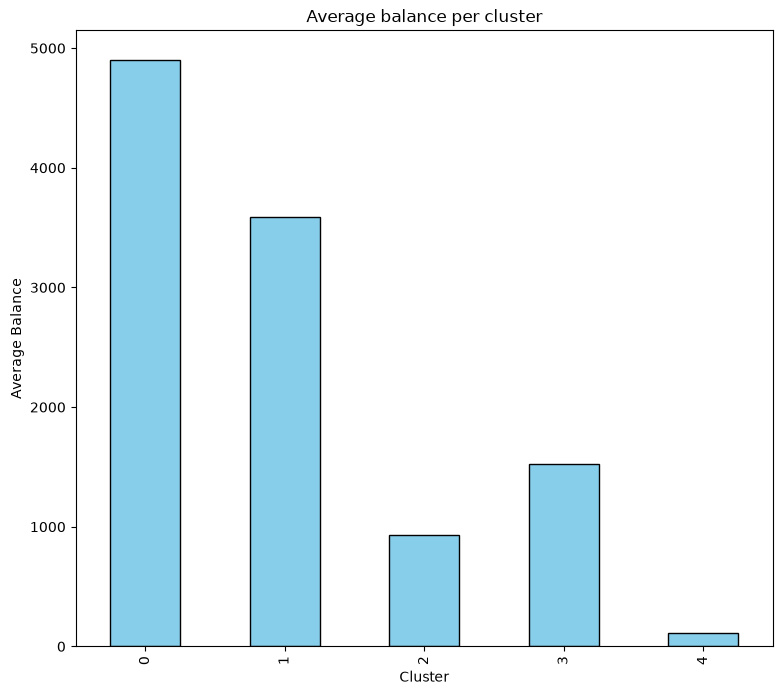

In [16]:
plt.figure(figsize=(9,8))
cluster_profile["BALANCE"].plot(kind="bar", color='skyblue', edgecolor="#010101")
plt.title("Average balance per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Balance")
plt.show()

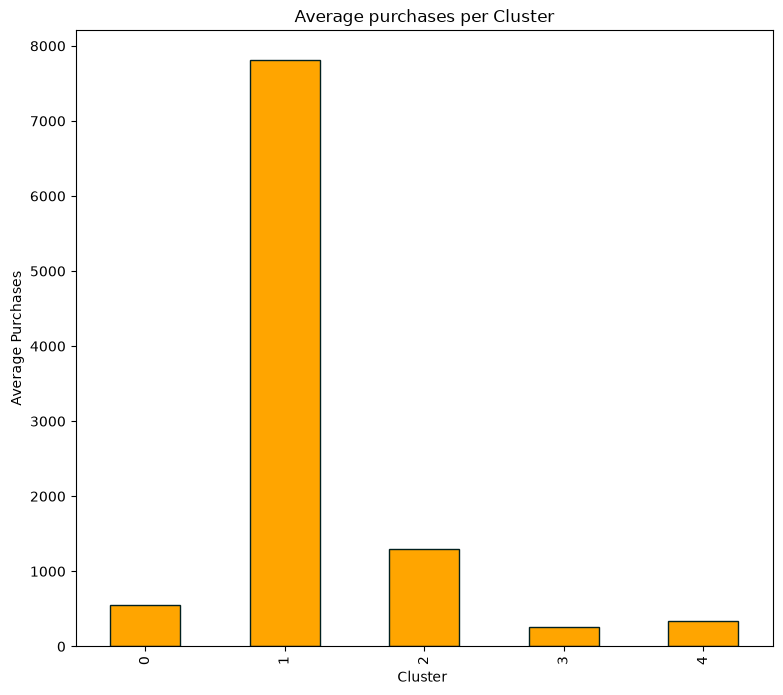

In [17]:
plt.figure(figsize=(9,8))
cluster_profile["PURCHASES"].plot(kind="bar", color="orange", edgecolor="#022020")
plt.title("Average purchases per Cluster")
plt.xlabel("Cluster ")
plt.ylabel("Average Purchases")
plt.show()

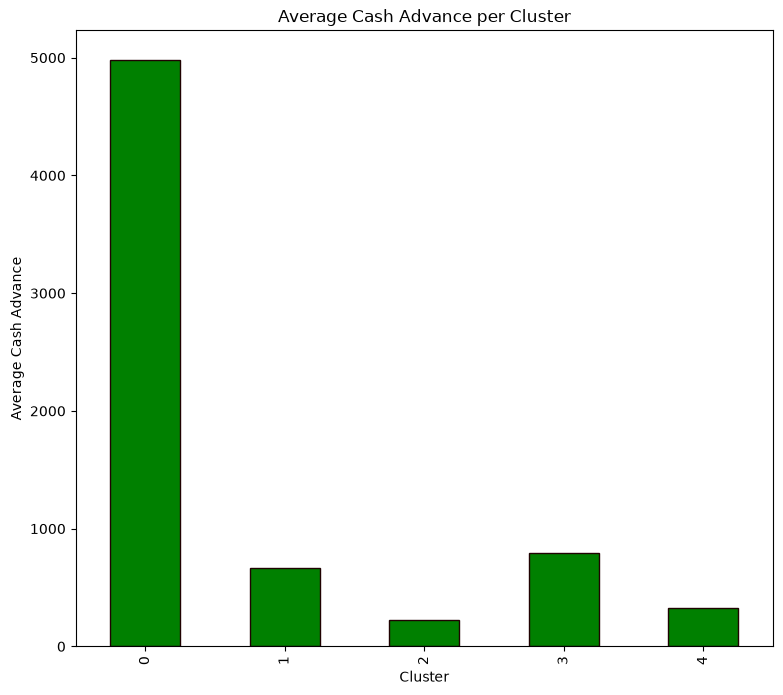

In [18]:
plt.figure(figsize=(9,8))
cluster_profile["CASH_ADVANCE"].plot(kind="bar", color="green", edgecolor="#200202")
plt.title("Average Cash Advance per Cluster")
plt.xlabel('Cluster')
plt.ylabel("Average Cash Advance")
plt.show()

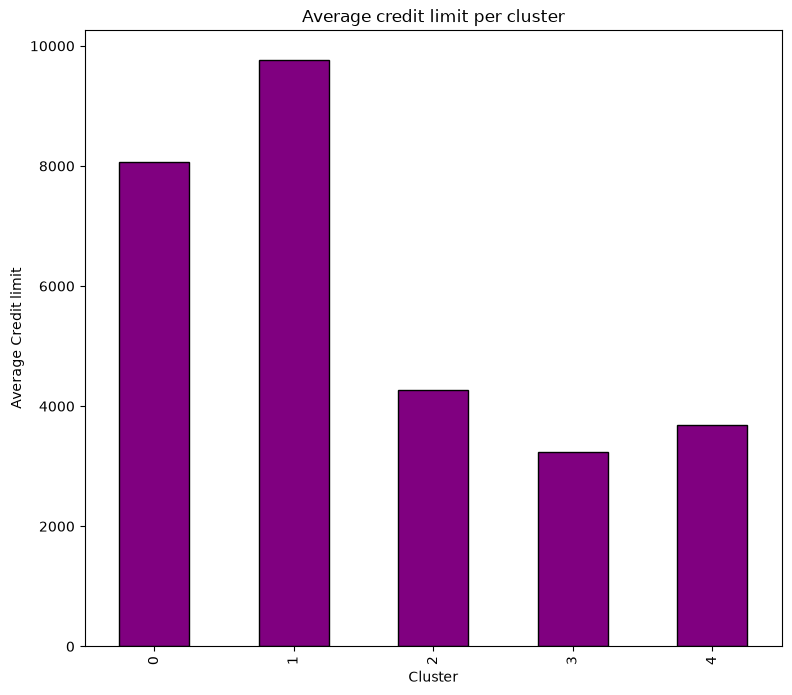

In [19]:
plt.figure(figsize=(9,8))
cluster_profile["CREDIT_LIMIT"].plot(kind="bar", color="purple", edgecolor="#010101")
plt.title("Average credit limit per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Credit limit")
plt.show()

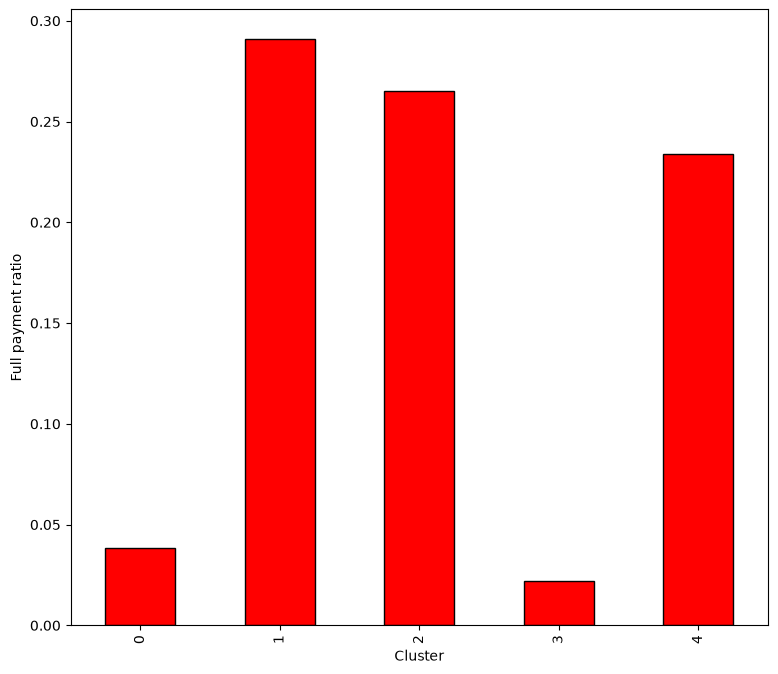

In [20]:
plt.figure(figsize=(9,8))
cluster_profile["PRC_FULL_PAYMENT"].plot(kind="bar", color="red", edgecolor="#030303")
plt.xlabel("Cluster")
plt.ylabel("Full payment ratio")
plt.show()

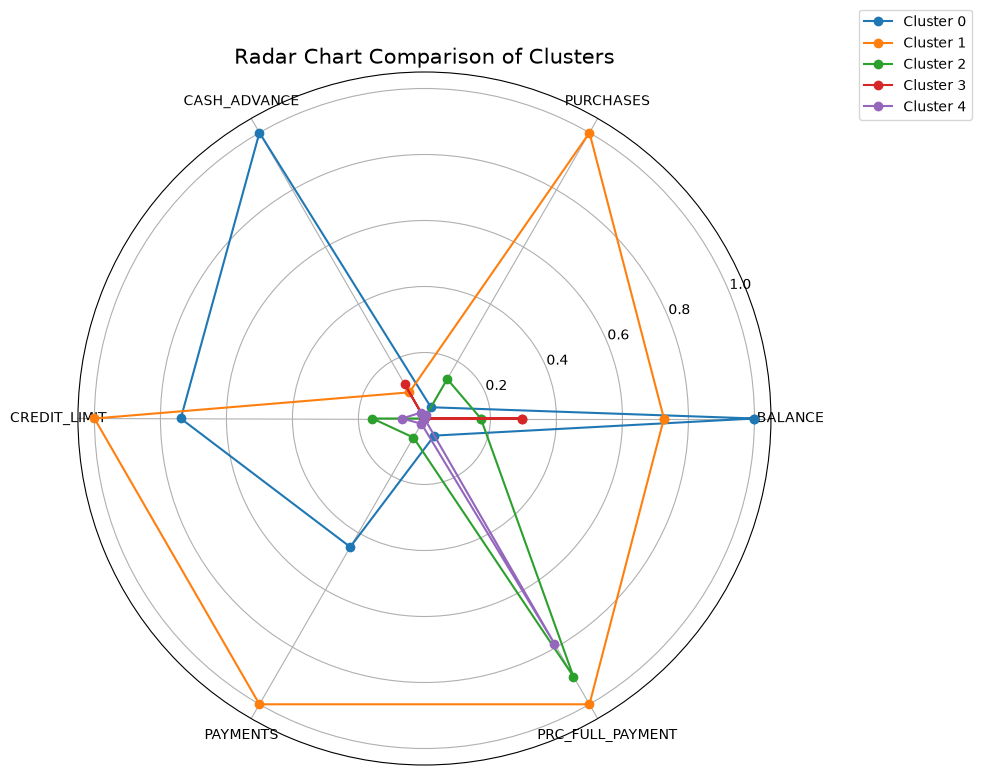

In [21]:
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']
    
data = cluster_profile[features]

data_norm = (data - data.min()) / (data.max() - data.min())

num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# Trying for K = 2

In [23]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_df)

df["Cluster"] = kmeans.labels_

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,1
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [24]:
df["Cluster"].value_counts()

Cluster
1    7090
0    1860
Name: count, dtype: int64

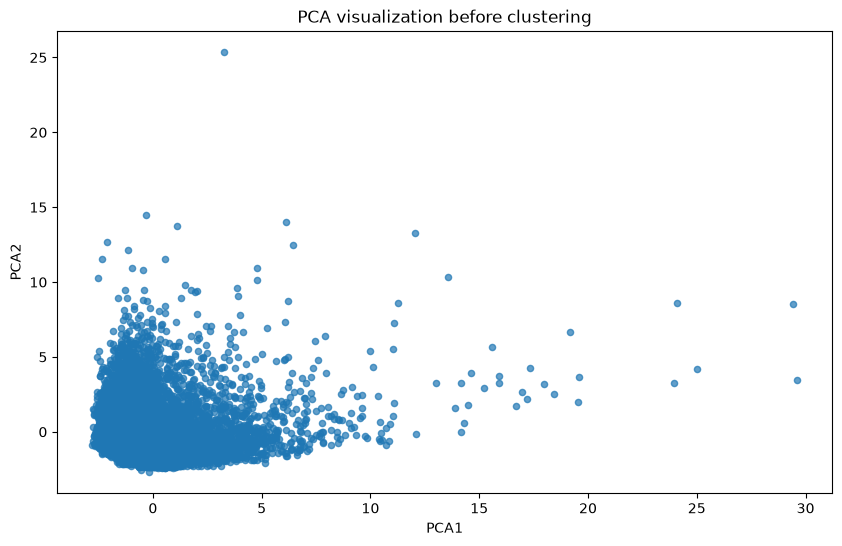

In [25]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(10,6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=20, alpha=0.7)
plt.title("PCA visualization before clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

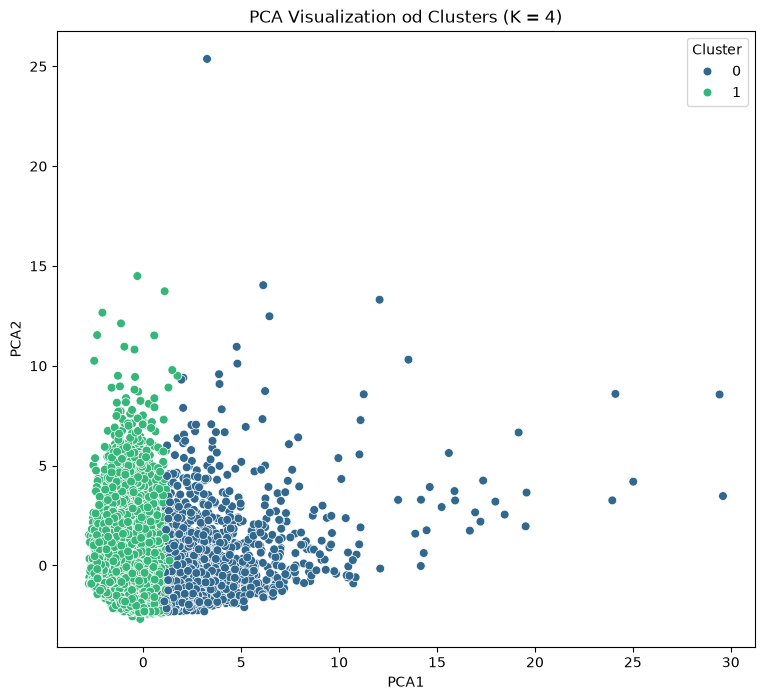

In [26]:
pca = PCA(n_components=2)
pca_components= pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])
pca_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(9,8))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="viridis", data=pca_df ,s=40)
plt.title("PCA Visualization od Clusters (K = 4)")
plt.show()

In [27]:
cluster_profile = df.drop(columns=["CUST_ID"]).groupby("Cluster").mean()

cluster_profile 

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2147.310087,0.979774,3364.893645,2075.077145,1290.139081,761.443235,0.937914,0.588182,0.712940,0.082253,2.232258,46.131183,7182.543988,3595.423358,1202.232987,0.285596,11.891935
1,1411.573053,0.850380,383.636260,203.479687,180.450879,1035.911430,0.372936,0.101266,0.273011,0.149020,3.515515,6.466714,3789.151688,1244.590977,772.383988,0.119117,11.419041


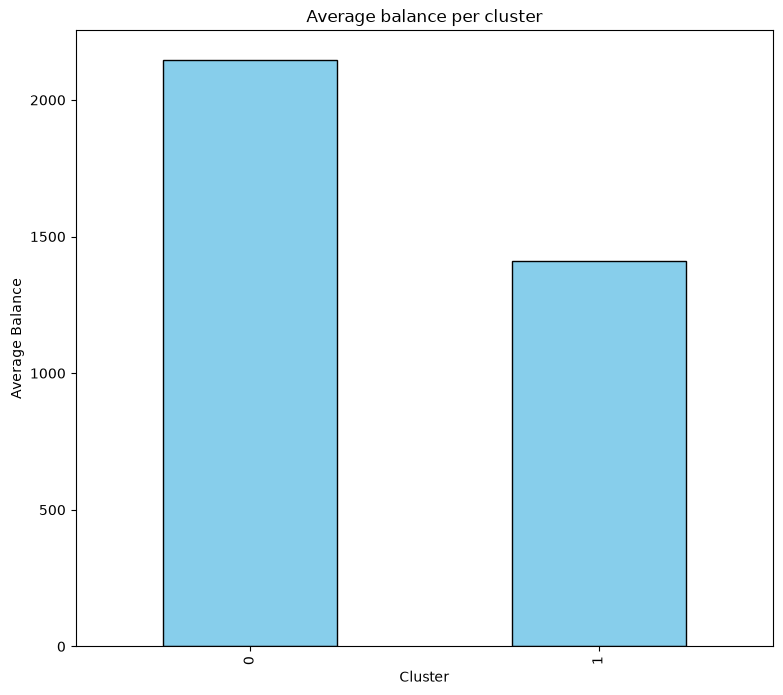

In [28]:
plt.figure(figsize=(9,8))
cluster_profile["BALANCE"].plot(kind="bar", color='skyblue', edgecolor="#010101")
plt.title("Average balance per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Balance")
plt.show()

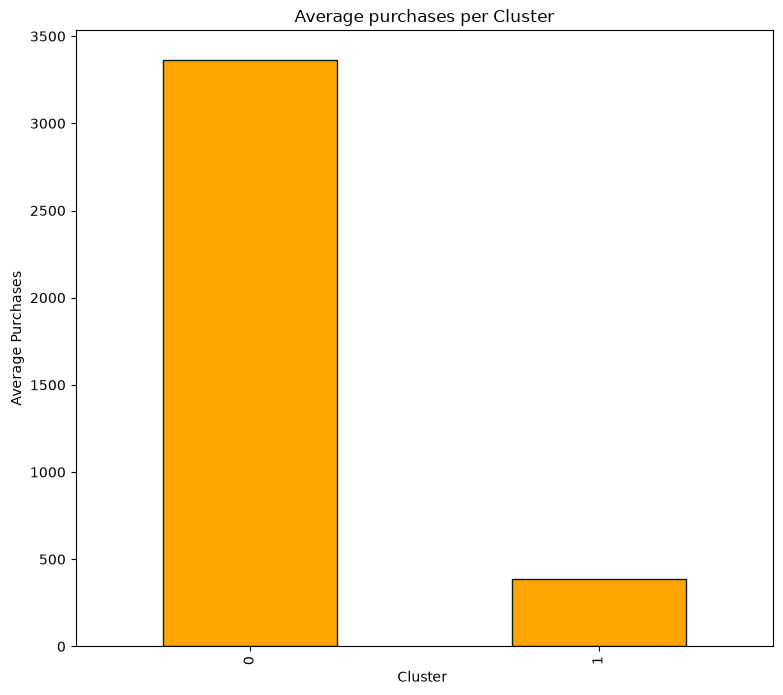

In [29]:
plt.figure(figsize=(9,8))
cluster_profile["PURCHASES"].plot(kind="bar", color="orange", edgecolor="#022020")
plt.title("Average purchases per Cluster")
plt.xlabel("Cluster ")  
plt.ylabel("Average Purchases")
plt.show()

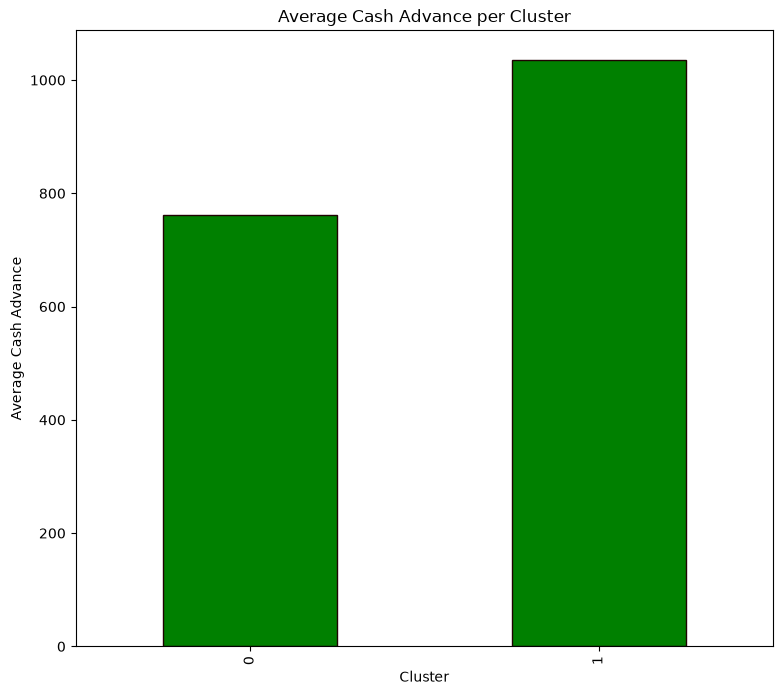

In [30]:
plt.figure(figsize=(9,8))
cluster_profile["CASH_ADVANCE"].plot(kind="bar", color="green", edgecolor="#200202")
plt.title("Average Cash Advance per Cluster")
plt.xlabel('Cluster')
plt.ylabel("Average Cash Advance")
plt.show()

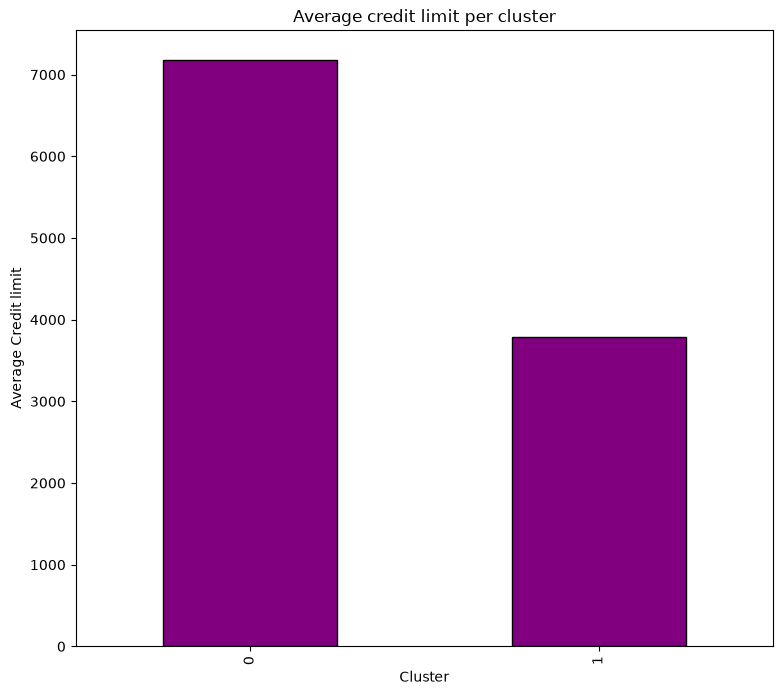

In [31]:
plt.figure(figsize=(9,8))
cluster_profile["CREDIT_LIMIT"].plot(kind="bar", color="purple", edgecolor="#010101")
plt.title("Average credit limit per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Credit limit")
plt.show()

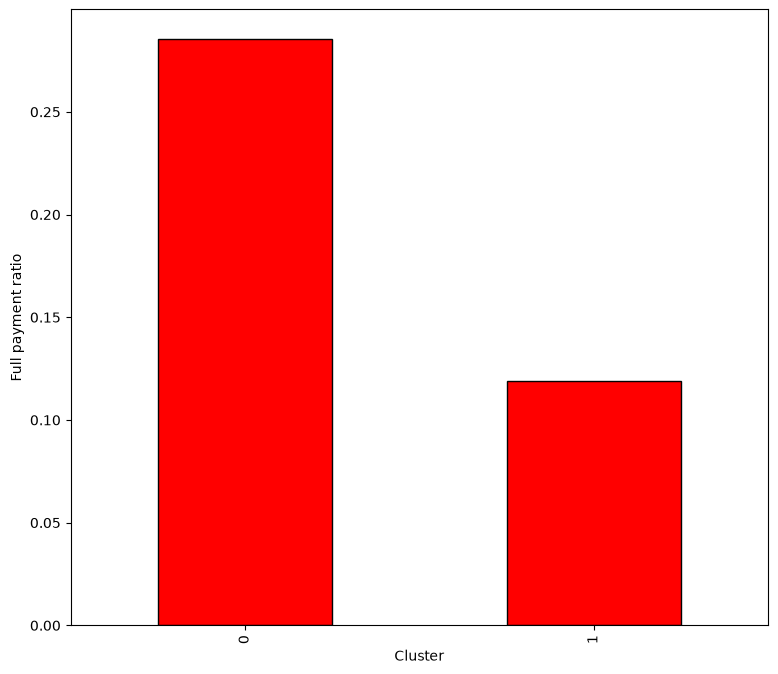

In [32]:
plt.figure(figsize=(9,8))
cluster_profile["PRC_FULL_PAYMENT"].plot(kind="bar", color="red", edgecolor="#030303")
plt.xlabel("Cluster")
plt.ylabel("Full payment ratio")
plt.show()

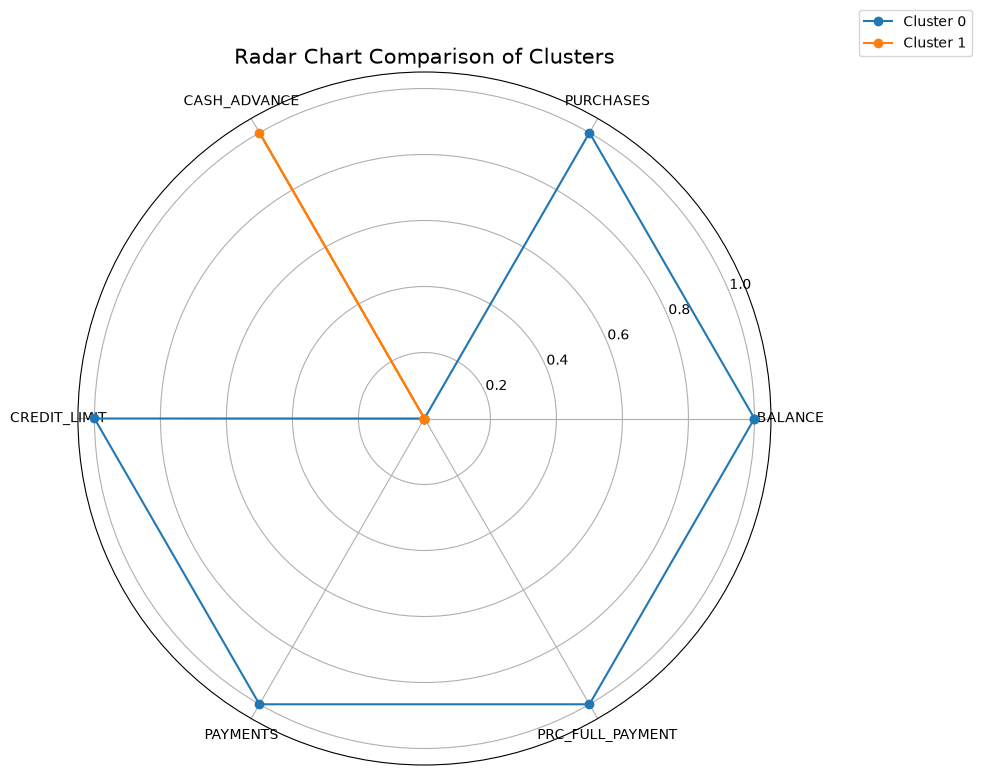

In [33]:
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']
    
data = cluster_profile[features]

data_norm = (data - data.min()) / (data.max() - data.min())

num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()